# 03 · Formulación, variables y modelos — el partido como unidad de estudio

**Pregunta del reto:** ¿qué principios definen al equipo en fase ofensiva y defensiva, cómo se manifiestan a lo largo del
tiempo y cómo se ajusta el comportamiento al contexto (rival, marcador, localía, momento)?

Este notebook sigue el **ciclo de vida de un proyecto de aprendizaje supervisado** (`Teoria ML/Aprendizaje_supervisado.pdf`):

| Etapa | Sección |
|---|---|
| 1. Definición del problema (T / E / P) | §1 |
| 2. Datos: capas medallion, marco analítico, ingeniería y evaluación de variables, *data leakage* | §2 |
| 3. Partición y validación | §3 |
| 4. Modelado (supervisado T1–T7, no supervisado U1–U3) y supuestos | §4 |
| 5. Evaluación en la prueba temporal | §5 |
| 6. Implementación y monitoreo: model cards, scoring, fichas automáticas, *drift* | §6 |

**Decisiones de diseño**
- La **unidad de estudio es el partido** (y sus derivados: posesión, tramo, balón parado, sustitución, jugador × partido).
- El entrenador **no es variable**: queda como metadato (`team_manager`) para particiones posteriores.
- Todo se lee de las capas **Gold** del pipeline (`python -m src.pipeline run --stages bronze,silver,gold,train,score,report`).
  Las definiciones viven en `src/framework.py` (marco) y `src/features.py` (variables); nada se redefine aquí.
- Las tablas de resultados se guardan en `data/gold/analysis/` y las figuras en `reports/figures/framework/`
  (insumos del reporte `reports/framework/framework_report.pdf`).

In [1]:
import sys, warnings, subprocess, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import eda, framework as fw, features as F, modeling as M, evaluation as E
from src.pipeline.config import GOLD, MODELS, REPORTS
from src.pipeline.silver import load_events
from src.pipeline.monitoring import drift_report

eda.set_style()
pd.set_option("display.max_columns", 40, "display.max_rows", 120, "display.width", 250,
              "display.float_format", lambda v: f"{v:,.3f}")
FIG = ROOT / "reports" / "figures" / "framework"; FIG.mkdir(parents=True, exist_ok=True)
E.ANALYSIS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

def keep(df, name):
    # guarda la tabla (insumo del reporte) y la muestra
    out = df.copy()
    out.columns = [str(c) for c in out.columns]
    out.to_parquet(E.ANALYSIS / f"{name}.parquet")
    display(df)

g = M.load_gold()
dim, mf, poss, split = g["dim_match"], g["match_features"], g["fct_possession"], g["split"]
print(f"{len(dim)} partidos · {dim.match_date.min():%Y-%m-%d} → {dim.match_date.max():%Y-%m-%d}")

222 partidos · 2021-07-23 → 2026-09-28


## 1. Definición del problema

**Necesidad.** Que alguien que no vio los partidos entienda el estilo del equipo, sus ideas, cómo usa a sus jugadores y
cómo todo eso se repite, evoluciona y se ajusta al contexto.

**Formulación global (Mitchell):**
- **T (tarea):** describir, explicar y anticipar el comportamiento del equipo *por partido*.
- **E (experiencia):** 222 partidos de Liga MX (2021–2026) con eventos y 360 de StatsBomb.
- **P (desempeño):** generalización en una **prueba temporal** (los partidos más recientes) frente a un **baseline**,
  e interpretabilidad trazable al marco analítico.

La pregunta se descompone en tareas con su propia *y*, *x*, tipo de problema, modelos y métrica:

In [2]:
keep(M.TASKS, "tasks")

,nombre,reto,unidad (Gold),y,x,tipo,modelos,P
tarea,,,,,,,,
T1,Ajuste al contexto previo,5.2,match_features + dim_match,12 variables de estilo,"localía, fuerza del rival previa, fase, descan...",Regresión,Baseline → Ridge / LASSO → Árbol → KNN,"MAE, RMSE, R²"
T2,Ajuste intra-partido,5.2,fct_segment,estilo en el tramo,"estado del marcador, tramo de 15', localía, fa...",Regresión,Baseline → Ridge → Árbol,"MAE, R²"
T3,Principios que generan dominio,"5.1, 5.5",match_features,"OBV neto, diferencial np xG",24 métricas de proceso (sin resultado),Regresión,Baseline → LASSO (+bootstrap) → Árbol → KNN,"MAE, RMSE, R²"
T3b,Resultado,5.5,match_features,G / E / P,24 métricas de proceso,Multiclase,Clase mayoritaria → Logística softmax → Árbol,"F1 macro, exactitud, matriz de confusión"
T4,Posesión → ocasión,5.1,fct_possession,la posesión termina en tiro,"inicio (x, y), patrón, recuperación, marcador,...",Binaria desbalanceada,Tasa base → Logística → Árbol → KNN,"ROC-AUC, F1, Brier"
T5,Balón parado,5.4,fct_set_piece,el balón parado termina en tiro,"tipo, entrega, zona de destino, lado, altura",Binaria,Tasa base → Logística → Árbol,"ROC-AUC, Brier"
T6,Impacto de sustituciones,5.3,fct_substitution,"Δ OBV neto, Δ field tilt, Δ np xG (15' después...","minuto, marcador, n.º de cambios, líneas que s...",Regresión,Δ=0 / Δ medio → Ridge → Árbol,"MAE, R²"
T7,Distribución del juego,"5.3, 5.2",match_features,"Gini de toques/progresión, top-3 OBV, potencia...",contexto previo + inercia,Regresión,Baseline → Ridge / LASSO → Árbol → KNN,"MAE, R²"
U1,Ejes de estilo,"5.1, 5.2",match_features,—,12 variables de estilo,Reducción de dimensión,PCA (70 % varianza),varianza explicada


## 2. Datos

### 2.1 Arquitectura medallion (local, Parquet)

```
API StatsBomb ─extract─▶ BRONZE ─transform+validar─▶ SILVER ─construir─▶ GOLD ─▶ modelos · scores · fichas
                         JSON crudo inmutable       Parquet tipado,       tablas por caso de uso
                         + manifest (sha256)        validado, por season  (contrato con modelos y ficha)
```
- **Bronze** guarda la respuesta exacta de la API (`.json.gz`) y un manifest con URL, versión, fecha, status y sha256.
  Es incremental e idempotente: una segunda corrida descarga 0 recursos.
- **Silver** aplana con las mismas funciones de `statsbombpy` (leyendo Bronze, sin red) y pasa **compuertas de calidad**:
  cobertura de partidos, ids únicos, coordenadas en cancha, xG en todo tiro, marcador reconstruido = oficial.
  Si una falla, el pipeline se detiene (`QualityError`).
- **Gold** se reconstruye completo desde Silver con las definiciones del marco.

In [3]:
st = E.layer_status()
for k, v in st.items():
    display(Markdown(f"**{k.capitalize()}**")); keep(v, f"layers_{k}")

**Bronze**

,recursos,MB,status_200,vacios
endpoint,,,,
360-frames,222,"1,195.328",100.000,1
events,222,"1,234.839",100.000,0
lineups,222,6.254,100.000,0
matches,6,2.717,100.000,0
player-match-stats,222,42.588,100.000,0
team-match-stats,222,3.468,100.000,0


**Silver**

,filas,columnas / particiones
league_matches,1854,62
lineup_positions,9699,14
lineups,9317,16
matches,230,70
player_match_stats,6870,178
team_match_stats,444,208
events,736829,6
frames360,8925818,6


**Gold**

,filas,columnas
dim_match,222,18
fct_player_match,3458,44
fct_possession,47022,32
fct_segment,1995,50
fct_set_piece,12509,48
fct_substitution,703,25
match_features,222,88


**Prueba de la migración.** Silver reproduce exactamente los datos con los que se hizo el EDA (mismos 736,829 eventos e ids,
mismas sumas de xG y OBV); la verificación está en el log del pipeline. Por eso los hallazgos del EDA siguen siendo válidos
sobre las capas.

### 2.2 Marco analítico (reto 5.6) y su validación

`src/framework.py` es la **fuente única** de definiciones: posesión, secuencia ofensiva, zonas, fases (construcción, progresión,
finalización), transición ofensiva (recuperación → x ≥ 80 o tiro en ≤ 15 s), transición defensiva (5 s tras pérdida), alturas de
presión, PPDA, balón parado, estado del marcador, tramos y grupos de posición. Todos los umbrales están en `ASSUMPTIONS`:

In [4]:
keep(pd.Series({k: str(v) for k, v in fw.ASSUMPTIONS.items()}, name="valor").to_frame(), "assumptions")

,valor
pitch,"(120, 80)"
third_limits,"(40, 80)"
lane_limits,"(26.666666666666668, 53.333333333333336)"
box,"{'x_min': 102, 'y_min': 18, 'y_max': 62}"
danger_zone,"{'x_min': 90, 'y_min': 18, 'y_max': 62}"
offensive_sequence_min_passes,3
build_up_start_x_max,40
progression_from_x_max,60
transition_window_s,15
counterpress_window_s,5


Antes de usar las definiciones propias, se validan contra las de StatsBomb y contra la realidad (marcador, minutos):

In [5]:
val = E.framework_validations(mf, poss, dim)
keep(val, "validations")
assert val.cumple.dropna().all(), "alguna validación del marco no se cumple"

,validación,valor,criterio,cumple
0,Transición ofensiva (propia) marcada también p...,100.000,≥ 70,True
1,Posesiones is_transition de StatsBomb detectad...,31.139,informativo,None
2,PPDA propio vs PPDA StatsBomb (ρ Spearman),0.959,> 0.8,True
3,Posesión (tiempo) vs posesión StatsBomb (ρ),0.836,> 0.8,True
4,np xG/100 pos. vs np xG StatsBomb (ρ),0.971,> 0.8,True
5,Altura acciones def. vs defensive distance SB (ρ),0.714,> 0.6,True
6,Marcador reconstruido == oficial (% partidos),100.000,= 100,True
7,Minutos fct_player_match / minutos por alineac...,1.042,≈ 1,True


- Las transiciones propias son un **subconjunto estricto** de las de StatsBomb: todas las que marcamos también las marca
  StatsBomb, pero solo capturamos ~1/3 de las suyas. Es deliberado: la definición propia exige *llegar* a x ≥ 80 o tirar en
  ≤ 15 s (transición **efectiva**), mientras que `is_transition` marca cualquier posesión que nace de una recuperación.
- El PPDA propio (Duel sin "Aerial Lost" + intercepción + falta en x ≥ 48 contra pases rivales en x ≤ 72) ordena los
  partidos casi igual que el de StatsBomb (ρ ≈ 0.96).

**Sensibilidad de los umbrales.** Si una conclusión dependiera del umbral elegido, no sería robusta. Se recalculan las
métricas con valores alternativos y se mide si cambia el **orden** de los partidos:

In [6]:
ev = load_events()
ev = fw.add_game_state(ev[ev.match_id.isin(dim.match_id)])
sens = E.threshold_sensitivity(ev)
keep(sens, "sensitivity")

,supuesto,valor,base,métrica,media,rho_vs_base
0,transition_window_s,10.000,False,transition_poss_pct,13.994,0.905
1,transition_window_s,15.000,True,transition_poss_pct,17.791,1.000
2,transition_window_s,20.000,False,transition_poss_pct,19.928,0.960
3,press_high_x,55.000,False,high_press_pct,47.094,0.976
4,press_high_x,60.000,True,high_press_pct,41.984,1.000
5,press_high_x,65.000,False,high_press_pct,36.889,0.978
6,progressive_min_gain,0.200,False,prog_passes_per100,9.745,0.861
7,progressive_min_gain,0.250,True,prog_passes_per100,6.946,1.000
8,progressive_min_gain,0.300,False,prog_passes_per100,4.993,0.893


Con ρ ≥ 0.86 en todos los casos, mover los umbrales cambia el **nivel** de las métricas pero casi no el **orden** de los partidos:
las comparaciones entre partidos (lo que usan los modelos y la ficha) no dependen de la elección fina del umbral.

### 2.3 Ingeniería de variables por criterio

Todas las variables son **tasas o proporciones** (no conteos, que dependen de la duración y del ritmo del partido) y se calculan con
una sola función, `features.aggregate(ev, poss, keys)`, para cualquier agrupación: partido, tramo, mitad o ventana alrededor de un
cambio. Así partido y segmento comparten exactamente las mismas definiciones.

In [7]:
cat = pd.DataFrame([(k, F.label(k), *v) for k, v in {**F.FEATURES, **F.PLAYER_FEATURES}.items()],
                   columns=["variable", "etiqueta", "criterio", "definición", "dirección"]).set_index("variable")
keep(cat, "catalog")
print(cat.criterio.value_counts().to_string())

,etiqueta,criterio,definición,dirección
variable,,,,
gk_short_goal_kick_pct,Saques de meta cortos (%),Construcción,% de saques de meta cortos (longitud < 32 yd),+ = salida corta
buildup_passes_per_seq,Pases por construcción,Construcción,Pases medios por posesión de construcción (ini...,+ = elaboración
buildup_success_pct,Construcciones que llegan a campo rival (%),Construcción,% de construcciones que llegan a campo rival (...,+ = mejor salida
press_resistance_own_third,Precisión bajo presión en tercio propio (%),Construcción,Precisión de pase bajo presión en tercio propio,+ = resiste presión
prog_passes_per100,Pases progresivos /100 pases,Progresión,Pases progresivos por 100 pases,+ = más vertical
prog_carries_per100,Conducciones progresivas /100 pases,Progresión,Conducciones progresivas por 100 pases,+ = progresa conduciendo
prog_lane_left_pct,Progresión por izquierda (%),Progresión,% de pases progresivos que terminan en carril ...,carril
prog_lane_center_pct,Progresión por el centro (%),Progresión,% de pases progresivos que terminan en carril ...,carril
prog_lane_right_pct,Progresión por derecha (%),Progresión,% de pases progresivos que terminan en carril ...,carril


criterio
Uso de jugadores          14
Progresión                 8
Ocasiones                  8
Presión                    5
Construcción               4
Organización defensiva     4
Transiciones               4
Dominio                    4
Balón parado               4


**Uso de jugadores y distribución del juego (5.3).** Desde `fct_player_match` (jugador × partido) se agrega al partido:
- **concentración**: índice de Gini del OBV, de los toques y de las acciones progresivas;
- **dependencia**: participación del mejor jugador y de los 3 mejores en el OBV positivo;
- **reparto por línea**: % del OBV positivo por defensas, medios, bandas y delanteros;
- **potenciación**: OBV p90 de cada jugador frente a **su propia referencia previa** (media de sus 10 partidos anteriores,
  `shift(1)`, mínimo 3) → % de jugadores por encima y residuo medio;
- **rotación y ajustes**: cambios en el XI, cambios de sistema y minuto del primer cambio.

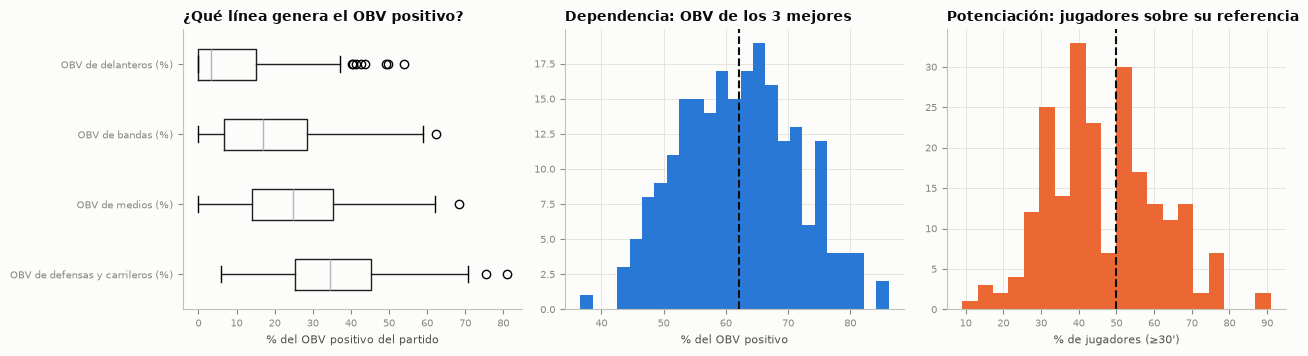

Mediana top-3: 62.2% · mediana top-1: 27.8% · mediana jugadores sobre referencia: 45.5%


In [8]:
pm = g["fct_player_match"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
share = mf[["obv_share_def", "obv_share_mid", "obv_share_wide", "obv_share_fwd"]].rename(columns=F.label)
share.boxplot(ax=axes[0], vert=False, grid=False)
axes[0].set_title("¿Qué línea genera el OBV positivo?", loc="left"); axes[0].set_xlabel("% del OBV positivo del partido")
axes[1].hist(mf.top3_obv_share, bins=25, color=eda.BLUE)
axes[1].axvline(mf.top3_obv_share.median(), color=eda.INK, ls="--")
axes[1].set_title("Dependencia: OBV de los 3 mejores", loc="left"); axes[1].set_xlabel("% del OBV positivo")
axes[2].hist(mf.boost_pct.dropna(), bins=20, color=eda.ORANGE)
axes[2].axvline(50, color=eda.INK, ls="--")
axes[2].set_title("Potenciación: jugadores sobre su referencia", loc="left"); axes[2].set_xlabel("% de jugadores (≥30')")
fig.tight_layout(); save(fig, "players_distribution")
print(f"Mediana top-3: {mf.top3_obv_share.median():.1f}% · mediana top-1: {mf.top1_obv_share.median():.1f}% · "
      f"mediana jugadores sobre referencia: {mf.boost_pct.median():.1f}%")

### 2.4 Evaluación de las variables como criterios → variables núcleo

Una métrica solo sirve como criterio si mide algo **del partido** y no ruido. Se evalúan seis propiedades:

| Propiedad | Cómo se mide | Por qué importa |
|---|---|---|
| Fiabilidad intra-partido | ρ(1er tiempo, 2º tiempo) corregida con Spearman-Brown | ¿el partido tiene un "valor verdadero" de la métrica? |
| Discriminación | ICC(1) con los dos tiempos como mediciones repetidas | varianza entre partidos / varianza total |
| Estabilidad temporal | autocorrelación lag-1 entre partidos consecutivos | ¿es un rasgo persistente o cambia partido a partido? |
| Sensibilidad al contexto | R² de localía + fuerza del rival + fase | ¿responde al contexto? (5.2) |
| Redundancia | máx. \|ρ\| con otra variable y VIF | supuesto de **no multicolinealidad** |
| Validez | ρ con OBV neto y diferencial de np xG | ¿se relaciona con dominar el partido? |

Las variables de nivel partido sin mitades (uso de jugadores) se juzgan por su estabilidad lag-1.

In [9]:
e_flags = F.event_flags(ev)
halves = E.half_features(e_flags, poss)
evtab = E.variable_evaluation(mf, halves)
core = E.select_core(evtab, mf)
keep(core[["etiqueta", "criterio", "fiabilidad_SB", "ICC1", "lag1", "R2_contexto", "max_abs_rho", "mas_parecida",
           "rho_obv_net", "rho_np_xg_diff", "nucleo", "motivo", "VIF"]].sort_values(["criterio", "nucleo"]), "variable_evaluation")
CORE = core[core.nucleo].index.tolist()
print(f"{len(CORE)} variables núcleo:", ", ".join(CORE))

,etiqueta,criterio,fiabilidad_SB,ICC1,lag1,R2_contexto,max_abs_rho,mas_parecida,rho_obv_net,rho_np_xg_diff,nucleo,motivo,VIF
variable,,,,,,,,,,,,,
sp_xg,xG a balón parado,Balón parado,0.224,0.077,-0.086,0.070,0.685,xg_share_set_piece,0.232,0.543,False,fiabilidad baja,NaN
opp_sp_xg,xG rival a balón parado,Balón parado,0.088,0.088,-0.029,0.021,0.711,opp_np_xg_per100poss,0.042,-0.476,False,fiabilidad baja,NaN
corner_shot_pct,Córners con tiro (%),Balón parado,0.101,0.071,-0.106,0.047,0.380,sp_xg,0.087,0.165,False,fiabilidad baja,NaN
opp_corner_shot_pct,Córners rivales con tiro (%),Balón parado,0.069,0.020,0.047,0.046,0.488,opp_sp_xg,0.033,-0.281,False,fiabilidad baja,NaN
press_resistance_own_third,Precisión bajo presión en tercio propio (%),Construcción,0.194,0.110,0.204,0.002,0.239,np_xg_diff,0.017,0.239,False,fiabilidad baja,NaN
gk_short_goal_kick_pct,Saques de meta cortos (%),Construcción,0.446,0.311,0.139,0.065,0.463,buildup_passes_per_seq,-0.044,0.171,True,,1.600
buildup_passes_per_seq,Pases por construcción,Construcción,0.397,0.219,0.051,0.093,0.599,field_tilt,0.070,0.285,True,,3.177
buildup_success_pct,Construcciones que llegan a campo rival (%),Construcción,0.371,0.211,0.206,0.077,0.667,progression_rate,0.008,0.216,True,,2.619
field_tilt,Field tilt (%),Dominio,0.550,0.400,-0.003,0.091,0.759,pass_x_mean,-0.089,0.333,False,VIF 10.1,NaN


29 variables núcleo: gk_short_goal_kick_pct, buildup_passes_per_seq, buildup_success_pct, prog_passes_per100, prog_carries_per100, prog_lane_center_pct, progression_rate, pass_x_mean, long_pass_pct, np_xg_per100poss, shots_per100poss, box_touches_per100poss, ppda, def_action_x_mean, counterpress_per_loss, opp_f3_entry_pct, block_x_mean, transition_poss_pct, transition_xg_per100poss, possession_time_pct, gini_touches, gini_prog, top1_obv_share, obv_share_mid, boost_pct, boost_mean, xi_rotation, tactical_shifts, first_sub_minute


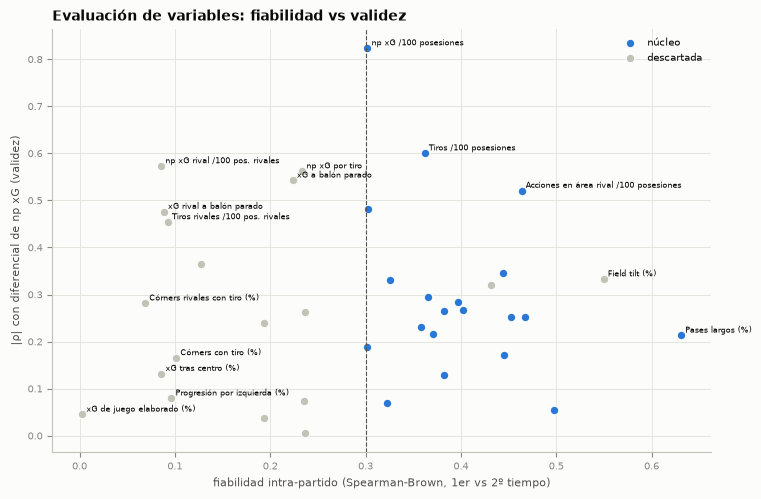

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
t = core.dropna(subset=["fiabilidad_SB"])
for flag, color, lab in [(True, eda.BLUE, "núcleo"), (False, "#c3c2b7", "descartada")]:
    s = t[t.nucleo == flag]
    ax.scatter(s.fiabilidad_SB, s.rho_np_xg_diff.abs(), s=40, color=color, label=lab, edgecolor=eda.SURFACE)
for v, r in t.iterrows():
    if r.fiabilidad_SB > 0.5 or abs(r.rho_np_xg_diff) > 0.5 or r.fiabilidad_SB < 0.12:
        ax.annotate(F.label(v), (r.fiabilidad_SB, abs(r.rho_np_xg_diff)), fontsize=6, xytext=(3, 2), textcoords="offset points")
ax.axvline(0.30, color=eda.INK_2, ls="--", lw=0.8)
ax.set_xlabel("fiabilidad intra-partido (Spearman-Brown, 1er vs 2º tiempo)")
ax.set_ylabel("|ρ| con diferencial de np xG (validez)")
ax.set_title("Evaluación de variables: fiabilidad vs validez", loc="left"); ax.legend()
save(fig, "variable_evaluation")

**Lectura.** Las métricas de volumen y altura (pases largos, field tilt, PPDA, altura de pase, saques cortos) son las más
fiables: reflejan un rasgo del partido que se sostiene entre tiempos. Las de **balón parado** y las de **xG concedido** tienen
fiabilidad muy baja por partido (dependen de pocos eventos raros): son útiles para describir *un* partido en la ficha,
pero no como criterio estable ni como variable explicativa.

### 2.5 Evolución en el tiempo (5.2)

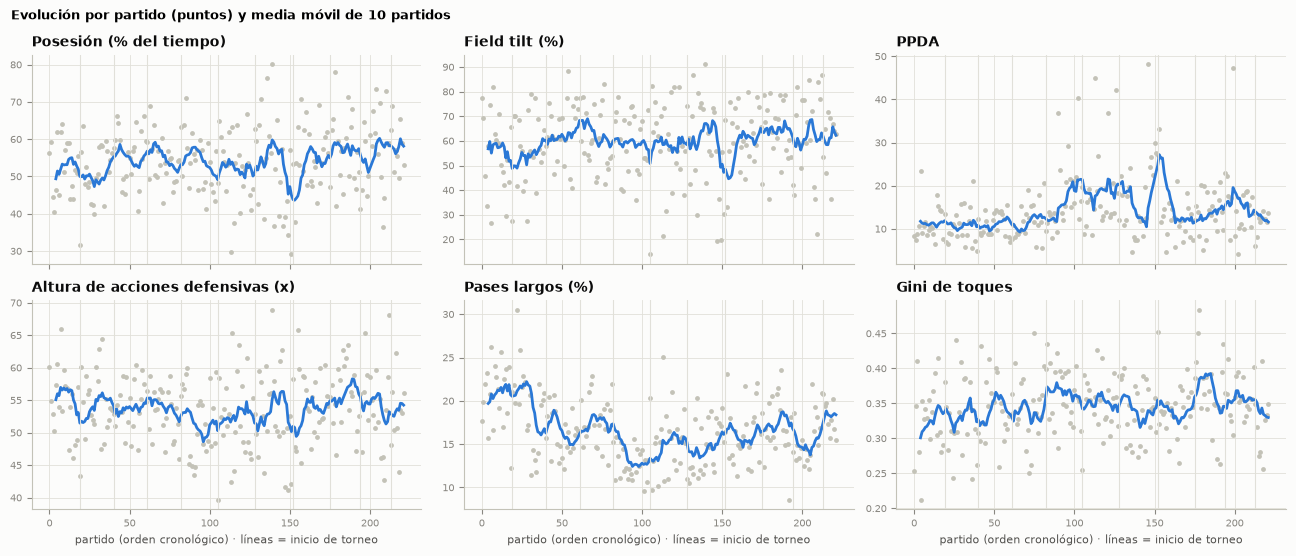

In [11]:
show_vars = ["possession_time_pct", "field_tilt", "ppda", "def_action_x_mean", "long_pass_pct", "gini_touches"]
d = mf.sort_values("match_order")
fig, axes = plt.subplots(2, 3, figsize=(13, 5.6), sharex=True)
bounds = d.groupby("torneo", sort=False).match_order.min()
for ax, v in zip(axes.flat, show_vars):
    ax.scatter(d.match_order, d[v], s=6, color="#c3c2b7")
    ax.plot(d.match_order, d[v].rolling(10, min_periods=5).mean(), color=eda.BLUE, lw=2)
    for b in bounds.values[1:]:
        ax.axvline(b, color=eda.GRID, lw=0.8)
    ax.set_title(F.label(v), loc="left")
for ax in axes[1]:
    ax.set_xlabel("partido (orden cronológico) · líneas = inicio de torneo")
fig.suptitle("Evolución por partido (puntos) y media móvil de 10 partidos", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "evolution")

### 2.6 Reglas contra *data leakage*

| Riesgo | Regla | Verificación |
|---|---|---|
| Fuerza del rival con partidos futuros | puntos por partido de los **17 partidos de liga previos** a la fecha | `test_rival_strength_uses_only_past` |
| Inercia con el propio partido | media móvil con `shift(1)` | `test_inertia_is_lagged` |
| Referencia de jugador con el propio partido | `shift(1)` + ventana de 10 | `test_player_reference_is_shifted` |
| Escalado, imputación, PCA, clústeres, percentiles con prueba | todo dentro de `Pipeline` y ajustado solo con train | diseño (`modeling.py`, `match_report.py`) |
| Objetivo disfrazado en T3 | x = solo métricas de **proceso** (sin xG, tiros, OBV) | `test_t3_has_no_outcome_features` |
| Posesiones o tramos del mismo partido en train y prueba | partición **por partido** | `test_temporal_split_no_overlap_and_ordered` |
| T4 usa lo que pasa durante la posesión | x = solo información **al inicio** | diseño (`POSS_NUM`, `POSS_CAT`) |

In [12]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", str(ROOT / "tests")], capture_output=True, text=True, cwd=ROOT)
print(r.stdout[-800:])

.........                                                                [100%]
9 passed in 2.64s



## 3. Partición y validación

- **Partición temporal 70 / 15 / 15** por partido: los datos no son independientes ni idénticamente distribuidos
  (el estilo evoluciona), así que una partición aleatoria filtraría el futuro. La **prueba** son los partidos más recientes
  y se usa **una sola vez**.
- **Selección de hiperparámetros**: validación cruzada de **ventana creciente** (`TimeSeriesSplit`, 4 pliegues) sobre
  train + validación, con `GridSearchCV`.
- **Baselines** (todo modelo debe superarlos): media histórica de entrenamiento y **media móvil de los 5 partidos previos**
  (inercia). En clasificación: clase mayoritaria o tasa base.

In [13]:
sp = dim.set_index("match_id").join(split)
tab = sp.groupby("split", sort=False).agg(partidos=("match_order", "size"), desde=("match_date", "min"),
                                          hasta=("match_date", "max"), torneos=("torneo", lambda s: ", ".join(s.unique())))
keep(tab.loc[["train", "val", "test"]], "split")

,partidos,desde,hasta,torneos
split,,,,
train,155,2021-07-23,2025-01-26,"Apertura 2021, Clausura 2022, Apertura 2022, C..."
val,33,2025-01-29,2025-10-19,"Clausura 2025, Apertura 2025"
test,34,2025-10-22,2026-09-28,"Apertura 2025, Clausura 2026, Apertura 2026"


## 4. Modelado

`M.train_all()` entrena las versiones base de todas las tareas y guarda una **model card** por modelo (§6). Aquí se
analizan sus resultados.

In [14]:
res = M.train_all()

2026-09-29 14:40:16,064 | INFO | modeling | Modelos base entrenados: 33 model cards


### T1 · Ajuste al contexto previo (5.2)

*y* = cada variable de estilo del partido; *x* = lo que se sabe **antes** del partido (localía, fuerza del rival, fase,
descanso, orden cronológico) + inercia (media de los 5 partidos previos). Candidatos: Ridge / LASSO (regularización L2 / L1),
árbol (no lineal, interpretable) y KNN.

In [15]:
rows = []
for y, r in res["T1"].items():
    t = r.table
    get = lambda m: t[(t.modelo == m) & (t.conjunto == "test")].MAE.iloc[0]
    rows.append({"variable": y, "etiqueta": F.label(y), "mejor (CV)": r.best_name, "MAE mejor": get(r.best_name),
                 "MAE media histórica": get("Baseline: media histórica (train)"), "MAE media móvil 5": get("Baseline: media móvil 5"),
                 "R2 mejor": t[(t.modelo == r.best_name) & (t.conjunto == "test")].R2.iloc[0],
                 "hiperparámetros": str(r.extra["params"])})
t1 = pd.DataFrame(rows).set_index("variable")
t1["MAE mejor baseline"] = t1[["MAE media histórica", "MAE media móvil 5"]].min(1)
t1["mejora vs mejor baseline (%)"] = (1 - t1["MAE mejor"] / t1["MAE mejor baseline"]) * 100
t1["supera"] = t1["mejora vs mejor baseline (%)"] > 0
keep(t1, "t1_results")
print(f"Superan al mejor baseline: {t1.supera.sum()} de {len(t1)}")

,etiqueta,mejor (CV),MAE mejor,MAE media histórica,MAE media móvil 5,R2 mejor,hiperparámetros,MAE mejor baseline,mejora vs mejor baseline (%),supera
variable,,,,,,,,,,
possession_time_pct,Posesión (% del tiempo),KNN,7.461,8.265,8.921,0.048,{'m__n_neighbors': 5},8.265,9.734,True
field_tilt,Field tilt (%),Ridge,12.538,13.437,14.975,0.022,{'m__alpha': 100},13.437,6.693,True
ppda,PPDA,KNN,4.663,4.754,5.481,0.059,{'m__n_neighbors': 10},4.754,1.906,True
def_action_x_mean,Altura de acciones defensivas (x),LASSO,4.405,4.469,5.410,0.007,{'m__alpha': 1.0},4.469,1.431,True
high_press_pct,Acciones defensivas en campo rival (%),Ridge,6.473,6.789,8.190,0.034,{'m__alpha': 100},6.789,4.646,True
pass_x_mean,Altura media de pase (x),LASSO,4.309,4.318,4.530,-0.050,{'m__alpha': 1.0},4.318,0.207,True
prog_passes_per100,Pases progresivos /100 pases,KNN,1.541,1.365,1.429,-0.371,{'m__n_neighbors': 10},1.365,-12.859,False
long_pass_pct,Pases largos (%),LASSO,2.231,2.331,2.432,0.018,{'m__alpha': 0.5},2.331,4.265,True
gk_short_goal_kick_pct,Saques de meta cortos (%),KNN,25.706,28.091,25.846,-0.306,{'m__n_neighbors': 20},25.846,0.541,True


Superan al mejor baseline: 8 de 12


**Lectura de T1.**
- El modelo supera al **mejor** de los dos baselines en 8 de 12 variables, pero con mejoras **modestas** (≈ 1–10 %) y un R²
  de prueba cercano a 0.
- La **media histórica** suele ser mejor que la inercia de 5 partidos. El estilo por partido se comporta como una
  **identidad estable más ruido**, no como una tendencia que se arrastra partido a partido.
- El contexto sí mueve el estilo de forma sistemática (ver coeficientes abajo), pero explica una fracción pequeña de la
  variación entre partidos.
- En las variables donde el modelo no supera al baseline (pases progresivos, transiciones, xG propio y rival), la ficha usa
  el baseline.

**Supuestos del modelo lineal (T1).** Se ajusta un OLS con las mismas *x* para diagnosticar los supuestos. La predicción
no los necesita, pero la **interpretación de coeficientes** sí:

In [16]:
la = E.linear_assumptions(mf, split, M.STYLE_TARGETS)
keep(la, "t1_assumptions")

,etiqueta,R2_train,Durbin_Watson,BP_p,JB_p,VIF_max,coef_local,p_local,coef_rival,p_rival,coef_inercia,p_inercia
variable,,,,,,,,,,,,
possession_time_pct,Posesión (% del tiempo),0.124,2.023,0.587,0.560,1.310,2.390,0.060,-5.778,0.000,0.229,0.130
field_tilt,Field tilt (%),0.135,1.963,0.321,0.035,1.242,6.202,0.004,-9.439,0.000,-0.064,0.681
ppda,PPDA,0.187,1.969,0.232,0.000,1.285,1.044,0.295,2.356,0.053,0.483,0.000
def_action_x_mean,Altura de acciones defensivas (x),0.117,2.057,0.283,0.588,1.251,2.790,0.000,-2.333,0.014,0.176,0.254
high_press_pct,Acciones defensivas en campo rival (%),0.118,2.149,0.258,0.677,1.251,4.231,0.000,-3.214,0.021,0.186,0.244
pass_x_mean,Altura media de pase (x),0.075,1.821,0.504,0.611,1.239,1.550,0.026,-1.735,0.040,0.290,0.038
prog_passes_per100,Pases progresivos /100 pases,0.055,2.066,0.426,0.708,1.230,0.399,0.067,0.593,0.026,0.192,0.197
long_pass_pct,Pases largos (%),0.277,1.792,0.708,0.153,1.360,0.221,0.663,2.034,0.001,0.636,0.000
gk_short_goal_kick_pct,Saques de meta cortos (%),0.130,1.912,0.377,0.052,1.236,0.901,0.805,-10.865,0.015,-0.125,0.421


- **Durbin-Watson ≈ 2** en casi todas: la inercia (media de 5 previos) absorbe la dependencia temporal.
- Donde **Breusch-Pagan** o **Jarque-Bera** rechazan (p < 0.05), los errores estándar clásicos no son confiables. Por eso
  la interpretación se apoya en el tamaño y la estabilidad del efecto, no en p-values aislados.
- **VIF máx. < 5**: sin multicolinealidad relevante entre las *x* de contexto.

**Efecto del contexto (coeficientes de OLS):**

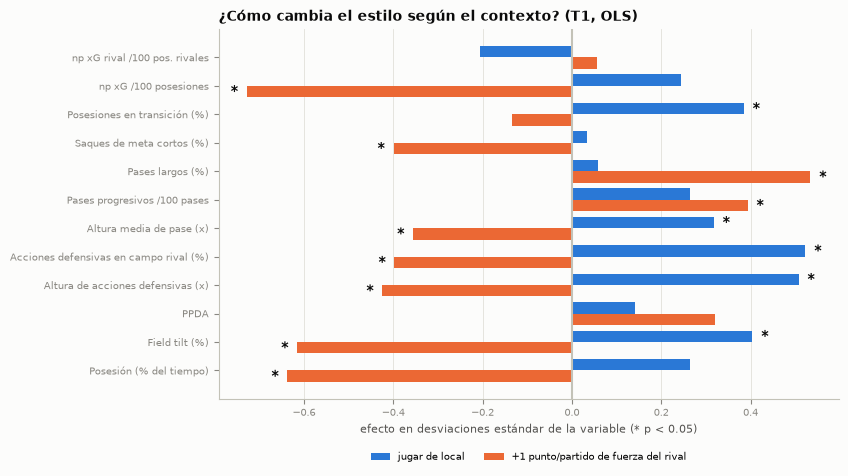

In [17]:
coef = la[["etiqueta", "coef_local", "p_local", "coef_rival", "p_rival", "coef_inercia", "p_inercia"]]
fig, ax = plt.subplots(figsize=(8, 4.8))
z = la[["coef_local", "coef_rival"]].div(mf[la.index].std(), axis=0)  # efecto en desviaciones estándar de la y
z.index = la.etiqueta
yy = np.arange(len(z))
ax.barh(yy + 0.2, z.coef_local, 0.4, color=eda.BLUE, label="jugar de local")
ax.barh(yy - 0.2, z.coef_rival, 0.4, color=eda.ORANGE, label="+1 punto/partido de fuerza del rival")
ax.set_yticks(yy, z.index); ax.axvline(0, color=eda.AXIS)
for i, (pl, pr) in enumerate(zip(la.p_local, la.p_rival)):
    for val, p_, off in [(z.coef_local.iloc[i], pl, 0.2), (z.coef_rival.iloc[i], pr, -0.2)]:
        if p_ < 0.05:  # asterisco por fuera del extremo de la barra, en tinta (no en el color de la serie)
            ax.text(val + (0.02 if val >= 0 else -0.02), i + off, "*", va="center", ha="left" if val >= 0 else "right",
                    color=eda.INK, fontsize=10, fontweight="bold")
ax.set_xlabel("efecto en desviaciones estándar de la variable (* p < 0.05)")
ax.set_title("¿Cómo cambia el estilo según el contexto? (T1, OLS)", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.grid(axis="y", visible=False)
save(fig, "t1_context_effects")

### T2 · Ajuste intra-partido: marcador y momento (5.2)

*y* = estilo en cada tramo de 15' × estado del marcador; *x* = estado del marcador, tramo, localía, fase, fuerza del rival.
Los coeficientes de Ridge para el **estado del marcador** (referencia: empate) muestran cómo cambia el comportamiento
cuando el equipo gana o pierde:

,etiqueta,MAE baseline,MAE Ridge,MAE Árbol,R2 Ridge
variable,,,,,
possession_time_pct,Posesión (% del tiempo),15.236,14.370,14.731,0.069
field_tilt,Field tilt (%),23.234,21.037,21.760,0.132
pass_x_mean,Altura media de pase (x),8.455,7.898,8.277,0.097
def_action_x_mean,Altura de acciones defensivas (x),9.624,9.189,9.202,0.066
high_press_pct,Acciones defensivas en campo rival (%),13.894,13.464,13.456,0.061
long_pass_pct,Pases largos (%),5.703,5.675,5.567,-0.006


,Pierde por 2+,Pierde por 1,Gana por 1,Gana por 2+
Posesión (% del tiempo),2.753,8.372,-5.298,-3.505
Field tilt (%),11.597,9.413,-12.815,-9.514
Altura media de pase (x),3.773,3.967,-3.720,-4.109
Altura de acciones defensivas (x),3.835,3.495,-4.823,-3.410
Acciones defensivas en campo rival (%),6.000,4.302,-6.834,-5.337
Pases largos (%),-0.078,-0.165,0.971,-0.539


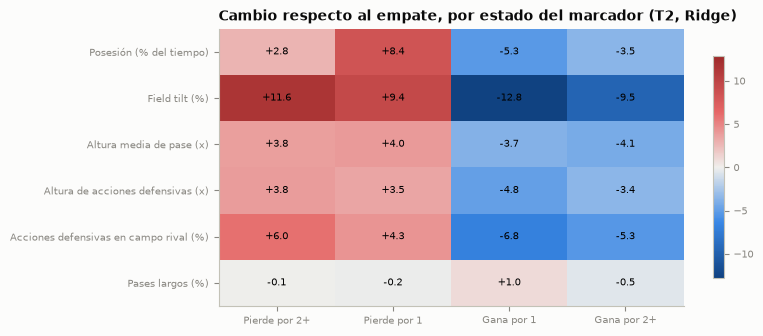

In [18]:
rows, coefs = [], {}
for y, r in res["T2"].items():
    t = r.table.set_index("modelo")
    rows.append({"variable": y, "etiqueta": F.label(y), "MAE baseline": t.loc["Baseline: media", "MAE"],
                 "MAE Ridge": t.loc["Ridge", "MAE"], "MAE Árbol": t.loc["Árbol", "MAE"], "R2 Ridge": t.loc["Ridge", "R2"]})
    c = r.extra["coef"]
    coefs[F.label(y)] = c[[i for i in c.index if i.startswith("game_state_")]]
keep(pd.DataFrame(rows).set_index("variable"), "t2_results")
gs = pd.DataFrame(coefs).T
gs.columns = [c.replace("game_state_", "") for c in gs.columns]
gs = gs[[c for c in ["Pierde por 2+", "Pierde por 1", "Gana por 1", "Gana por 2+"] if c in gs.columns]]
keep(gs, "t2_game_state_coefs")
m = np.nanmax(abs(gs.values))
fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(gs.values, cmap=eda.DIV, vmin=-m, vmax=m, aspect="auto")
ax.set_xticks(range(gs.shape[1]), gs.columns); ax.set_yticks(range(gs.shape[0]), gs.index)
for i in range(gs.shape[0]):
    for j in range(gs.shape[1]):
        ax.text(j, i, f"{gs.values[i, j]:+.1f}", ha="center", va="center", fontsize=7)
ax.set_title("Cambio respecto al empate, por estado del marcador (T2, Ridge)", loc="left"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "t2_game_state")

### T3 · Principios que generan dominio (5.1, 5.5) y T3b · resultado

*y* = OBV neto / diferencial de np xG; *x* = **solo métricas de proceso** (24), para que el modelo no "haga trampa" con
variables que ya contienen el resultado. LASSO selecciona variables; su **estabilidad** se mide con 100 remuestreos bootstrap
(% de veces que cada variable es elegida).

In [19]:
rows, stab = [], {}
for y, r in res["T3"].items():
    t = r.table.set_index("modelo")
    rows.append({"objetivo": y, "MAE baseline": t.loc["Baseline: media", "MAE"], "MAE LASSO": t.loc["LASSO", "MAE"],
                 "MAE Árbol": t.loc["Árbol", "MAE"], "MAE KNN": t.loc["KNN", "MAE"], "R2 LASSO": t.loc["LASSO", "R2"],
                 "alpha": r.best.named_steps["m"].alpha, "variables elegidas": int((r.extra["coef"] != 0).sum())})
    stab[y] = pd.DataFrame({"coef": r.extra["coef"], "estabilidad": r.extra["stability"]})
keep(pd.DataFrame(rows).set_index("objetivo"), "t3_results")
s = stab["np_xg_diff"].assign(etiqueta=lambda d: d.index.map(F.label)).sort_values("estabilidad", ascending=False)
keep(s[s.estabilidad > 0.3], "t3_lasso_np_xg_diff")

,MAE baseline,MAE LASSO,MAE Árbol,MAE KNN,R2 LASSO,alpha,variables elegidas
objetivo,,,,,,,
obv_net,1.408,1.408,1.507,1.483,-0.001,0.500,0
np_xg_diff,0.655,0.548,0.556,0.581,0.130,0.100,6


,coef,estabilidad,etiqueta
box_touches_per100poss,0.355,1.000,Acciones en área rival /100 posesiones
gini_touches,0.100,0.930,Gini de toques
press_resistance_own_third,0.072,0.860,Precisión bajo presión en tercio propio (%)
prog_passes_per100,0.031,0.740,Pases progresivos /100 pases
opp_f3_entry_pct,-0.075,0.720,Posesiones rivales que llegan a último tercio (%)
buildup_passes_per_seq,0.004,0.370,Pases por construcción
def_action_x_mean,0.000,0.310,Altura de acciones defensivas (x)


- Para el **diferencial de np xG**, un pequeño conjunto de principios de proceso mejora al baseline: son los rasgos que,
  partido a partido, acompañan a generar más ocasiones que el rival.
- Para el **OBV neto**, la validación cruzada elige el modelo nulo: ninguna métrica de proceso lo explica mejor que la media
  (|ρ| máx. ≈ 0.14). El OBV neto de un partido es muy ruidoso; el diferencial de xG es mejor objetivo para "dominio".

In [20]:
r = res["T3b"]
keep(r.table.set_index("modelo"), "t3b_results")
keep(r.extra["confusion"]["Logística softmax"], "t3b_confusion")

,accuracy,F1_macro
modelo,,
Baseline: clase mayoritaria (W),0.471,0.213
Logística softmax,0.353,0.289
Árbol,0.353,0.338


,W,D,L
W,5,3,8
D,3,0,6
L,1,1,7


### T4 · Posesión → ocasión (5.1) y T5 · balón parado (5.4)

Clasificación binaria desbalanceada (solo ~12 % de las posesiones termina en tiro). Se usa `class_weight="balanced"`,
que mejora la **discriminación** (ROC-AUC) pero descalibra las probabilidades (Brier peor que la tasa base). Para
comparar posesiones basta con discriminar bien; para usar la probabilidad como tal habría que recalibrarla.

In [21]:
keep(res["T4"].table.set_index("modelo"), "t4_results")
c = res["T4"].extra["coef"].sort_values()
keep(pd.concat([c.head(6), c.tail(6)]).to_frame("coef (log-odds, x estandarizadas)"), "t4_coefs")
for k in ["T5_favor", "T5_contra"]:
    display(Markdown(f"**{k}**")); keep(res[k].table.set_index("modelo"), f"{k.lower()}_results")
rates = res["T5_favor"].extra["rates"]
keep(rates[rates.jugadas >= 20].sort_values("pct_tiro", ascending=False), "t5_rates")

,ROC_AUC,PR_AUC(prevalencia),F1,Brier
modelo,,,,
Baseline: tasa base,0.500,0.123,NaN,0.123
Logística,0.724,NaN,0.361,0.217
Árbol,0.696,NaN,0.335,0.211
KNN,0.708,NaN,0.093,0.110


,"coef (log-odds, x estandarizadas)"
play_pattern_From Kick Off,-1.219
play_pattern_From Throw In,-0.662
play_pattern_From Keeper,-0.394
play_pattern_From Goal Kick,-0.324
play_pattern_Regular Play,-0.279
start_y_abs,-0.219
minute_bin_45-60,0.253
minute_bin_60-75,0.310
minute_bin_90+,0.340
minute_bin_75-90,0.347


**T5_favor**

,ROC_AUC,PR_AUC(prevalencia),F1,Brier
modelo,,,,
Baseline: tasa base,0.500,0.184,NaN,0.174
Logística,0.692,NaN,0.482,0.213
Árbol,0.680,NaN,0.463,0.209


**T5_contra**

,ROC_AUC,PR_AUC(prevalencia),F1,Brier
modelo,,,,
Baseline: tasa base,0.500,0.165,NaN,0.128
Logística,0.714,NaN,0.415,0.203
Árbol,0.705,NaN,0.378,0.201


jugadas  pct_tiro     xg
kind           target_zone                              
Córner         Zona de penal        536     0.451 22.085
               Área (costados)       78     0.359  1.787
Tiro libre     Área chica            64     0.312  3.543
Saque de banda Zona de penal         27     0.296  0.467
Tiro libre     Zona de penal        291     0.296  8.201
Córner         Área chica           224     0.286  8.862
               Corto                428     0.259 12.153
Tiro libre     Corto                960     0.237 16.662
Córner         Fuera del área       362     0.191  9.262
Saque de banda Área (costados)      164     0.140  1.677
Tiro libre     Área (costados)      125     0.136  1.605
Saque de banda Fuera del área       768     0.133  9.946
               Corto                709     0.100  6.988
Tiro libre     Fuera del área      1899     0.100 25.623

### T6 · Impacto de las sustituciones (5.3)

*y* = cambio en OBV neto, field tilt y np xG entre los 15' anteriores y los 15' posteriores a una intervención
(cambios en el mismo minuto). Se comparan dos baselines: "el cambio no hace nada" (Δ = 0) y el Δ medio.

In [22]:
rows = []
for y, r in res["T6"].items():
    t = r.table.set_index("modelo")
    rows.append({"objetivo": y, **{m: t.loc[m, "MAE"] for m in t.index}, "R2 Ridge": t.loc["Ridge", "R2"]})
keep(pd.DataFrame(rows).set_index("objetivo"), "t6_results")
keep(res["T6"]["d_field_tilt"].extra["by_state"], "t6_by_state")

,Baseline: sin cambio (Δ=0),Baseline: Δ medio,Ridge,Árbol,R2 Ridge
objetivo,,,,,
d_obv_net,0.670,0.675,0.685,0.686,0.036
d_field_tilt,22.003,21.994,22.340,22.277,-0.044
d_np_xg_diff,0.300,0.301,0.303,0.314,-0.018


,mean,median,size
game_state,,,
Empate,1.250,2.143,213
Gana por 1,-6.544,-7.386,127
Gana por 2+,2.162,0.995,142
Pierde por 1,4.195,0.714,87
Pierde por 2+,11.765,11.695,42


Ningún modelo supera al Δ medio: con la información disponible, el efecto de un cambio es **impredecible** a nivel
intervención. Es un resultado honesto y útil: la ficha describe el antes y el después de cada cambio, pero no promete su efecto.

### T7 · Distribución del juego según el contexto (5.3 + 5.2)

In [23]:
rows = []
for y, r in res["T7"].items():
    t = r.table
    get = lambda m: t[(t.modelo == m) & (t.conjunto == "test")].MAE.iloc[0]
    rows.append({"variable": y, "etiqueta": F.label(y), "mejor (CV)": r.best_name, "MAE mejor": get(r.best_name),
                 "MAE media móvil 5": get("Baseline: media móvil 5"), "MAE media histórica": get("Baseline: media histórica (train)")})
keep(pd.DataFrame(rows).set_index("variable"), "t7_results")

,etiqueta,mejor (CV),MAE mejor,MAE media móvil 5,MAE media histórica
variable,,,,,
gini_touches,Gini de toques,Ridge,0.036,0.039,0.033
gini_prog,Gini de progresión,LASSO,0.064,0.063,0.064
top3_obv_share,OBV de los 3 mejores (%),Árbol,7.803,8.417,8.017
boost_mean,OBV p90 vs referencia (media),LASSO,0.101,0.102,0.101


### U1 / U2 · Ejes de estilo y tipos de partido (no supervisado)

PCA sobre las 12 variables de estilo (ajustado **solo con train**; se retienen las componentes que explican el 70 % de la
varianza). Luego K-means sobre las componentes, con *k* elegido por silhouette.

In [24]:
sp_ = res["U1U2"]
expl = pd.DataFrame({"varianza": sp_["explained"], "acumulada": np.cumsum(sp_["explained"])},
                    index=[f"PC{i+1}" for i in range(len(sp_["explained"]))])
keep(expl, "u1_explained")
L = sp_["loadings"].copy(); L.index = [F.label(i) for i in L.index]
keep(L, "u1_loadings")
keep(pd.Series(sp_["silhouette"], name="silhouette").to_frame(), "u2_silhouette")
sc = sp_["scores"].join(mf.set_index("match_id")[["torneo", "match_order"] + M.STYLE_TARGETS])
prof = sc[sc.index.map(split) == "train"].groupby("tipo_partido")[M.STYLE_TARGETS].mean().T
prof.index = [F.label(i) for i in prof.index]
keep(prof, "u2_profiles")

,varianza,acumulada
PC1,0.380,0.380
PC2,0.128,0.507
PC3,0.105,0.613
PC4,0.087,0.699
PC5,0.073,0.772


,PC1,PC2,PC3,PC4,PC5
Posesión (% del tiempo),0.359,0.006,-0.208,0.224,-0.315
Field tilt (%),0.433,-0.047,-0.138,0.107,-0.005
PPDA,-0.215,-0.463,0.141,-0.164,0.413
Altura de acciones defensivas (x),0.402,0.109,-0.085,-0.267,0.304
Acciones defensivas en campo rival (%),0.383,0.111,-0.092,-0.310,0.341
Altura media de pase (x),0.377,0.112,-0.007,0.280,0.071
Pases progresivos /100 pases,0.078,0.354,0.655,0.286,-0.137
Pases largos (%),-0.175,0.568,0.011,-0.098,0.089
Saques de meta cortos (%),0.182,-0.445,-0.045,0.033,-0.420
Posesiones en transición (%),0.283,-0.075,0.287,-0.014,0.270


,silhouette
2,0.265
3,0.209
4,0.198
5,0.186
6,0.173


tipo_partido,0,1
Posesión (% del tiempo),57.980,46.071
Field tilt (%),68.829,44.344
PPDA,11.683,18.526
Altura de acciones defensivas (x),56.273,48.891
Acciones defensivas en campo rival (%),45.501,35.543
Altura media de pase (x),60.923,54.594
Pases progresivos /100 pases,7.096,6.734
Pases largos (%),15.788,17.660
Saques de meta cortos (%),48.080,30.683
Posesiones en transición (%),19.420,15.417


tipo_partido,0,1
torneo,,
Apertura 2021,52.632,47.368
Clausura 2022,66.667,33.333
Apertura 2022,71.429,28.571
Clausura 2023,61.905,38.095
Apertura 2023,60.870,39.130
Clausura 2024,52.174,47.826
Apertura 2024,45.833,54.167
Clausura 2025,60.870,39.130
Apertura 2025,73.684,26.316


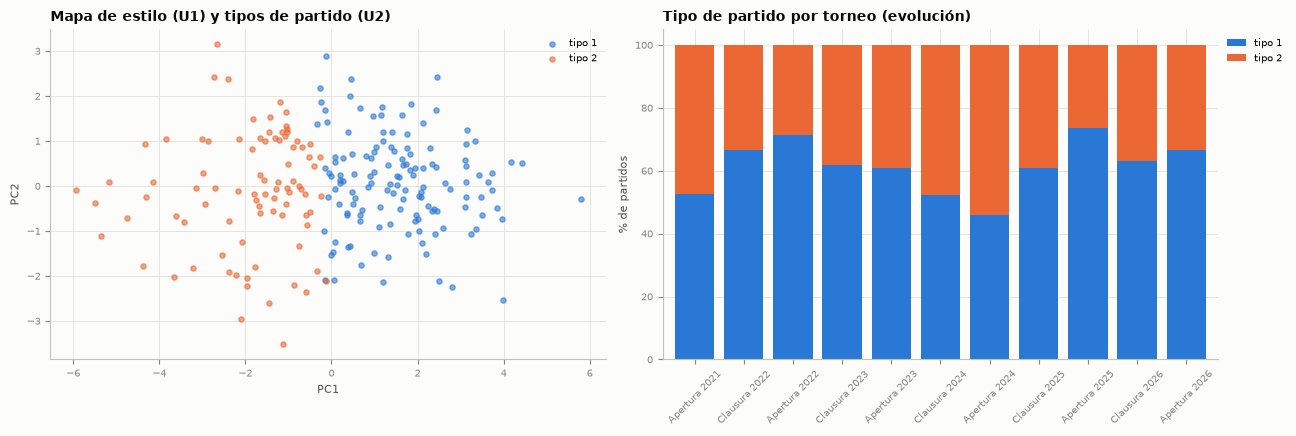

In [25]:
evo = pd.crosstab(sc.torneo, sc.tipo_partido, normalize="index").reindex(mf.drop_duplicates("torneo").torneo) * 100
keep(evo, "u2_by_torneo")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
for k, dd in sc.groupby("tipo_partido"):
    ax.scatter(dd.PC1, dd.PC2, s=14, alpha=.6, label=f"tipo {k+1}", color=[eda.BLUE, eda.ORANGE, eda.RED, "#1baf7a", "#4a3aa7", "#eda100"][k])
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(); ax.set_title("Mapa de estilo (U1) y tipos de partido (U2)", loc="left")
ax = axes[1]
evo.plot(kind="bar", stacked=True, ax=ax, color=[eda.BLUE, eda.ORANGE, eda.RED, "#1baf7a", "#4a3aa7", "#eda100"][:evo.shape[1]], width=0.8)
ax.set_ylabel("% de partidos"); ax.set_xlabel(""); ax.set_title("Tipo de partido por torneo (evolución)", loc="left")
ax.legend([f"tipo {k+1}" for k in evo.columns], fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); save(fig, "u1u2_style")

### U3 · Roles de jugador (5.3)

K-means sobre perfiles p90 (jugador × partido con ≥ 30', sin porteros), ajustado con train. Cada rol se describe por
sus acciones distintivas (centroide estandarizado) y por las posiciones que lo ocupan.

,rol,posición dominante,% posición dominante,jugador-partidos
0,Rol 1: touches + passes,Medio defensivo,58.000,395
1,Rol 2: interceptions + ball_recoveries,Defensa,67.000,971
2,Rol 3: xa + obv_pass,Banda,37.000,155
3,Rol 4: np_xg + pressures,Delantero,42.000,688
4,Rol 5: dribbles + obv_dribble_carry,Banda,53.000,331


,silhouette
4,0.110
5,0.115
6,0.107
7,0.105
8,0.107
9,0.088


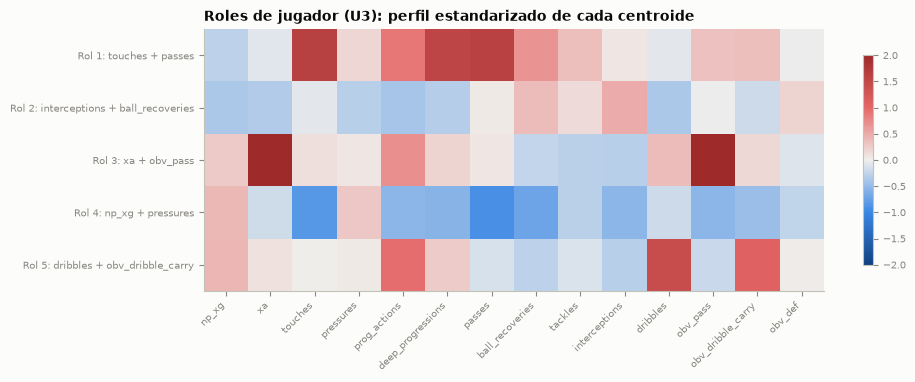

In [26]:
ro = res["U3"]
cent = ro["centroids"].copy()
names = {k: " + ".join(cent.loc[k].nlargest(2).index.str.replace("_p90", "")) for k in cent.index}
comp = ro["composition"]
roles = pd.DataFrame({"rol": [f"Rol {k+1}: {names[k]}" for k in cent.index],
                      "posición dominante": comp.idxmax(1).values, "% posición dominante": comp.max(1).values * 100,
                      "jugador-partidos": ro["assign"].role.value_counts().sort_index().values})
keep(roles, "u3_roles")
keep(pd.Series(ro["silhouette"], name="silhouette").to_frame(), "u3_silhouette")
fig, ax = plt.subplots(figsize=(10, 3.4))
im = ax.imshow(cent.values, cmap=eda.DIV, vmin=-2, vmax=2, aspect="auto")
ax.set_yticks(range(len(cent)), roles.rol); ax.set_xticks(range(cent.shape[1]), cent.columns.str.replace("_p90", ""), rotation=45, ha="right")
ax.set_title("Roles de jugador (U3): perfil estandarizado de cada centroide", loc="left"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8); save(fig, "u3_roles")

## 5. Evaluación en la prueba temporal

Resumen de todas las model cards (la prueba se usó una sola vez). Diagnóstico de **sobreajuste**: se compara el error en
entrenamiento con el de prueba para el mejor modelo de T1.

In [27]:
cards = pd.DataFrame([json.loads(f.read_text(encoding="utf-8")) for f in sorted(MODELS.glob("*.json"))]).set_index("name")
cols = [c for c in ["task", "model", "test_MAE", "baseline_MAE", "test_ROC_AUC", "test_F1_macro", "baseline_F1_macro",
                    "beats_baseline", "k", "data_hash"] if c in cards]
keep(cards[cols], "model_cards")
print(f"Supera al baseline: {int(cards.beats_baseline.fillna(False).astype(bool).sum())} de {cards.beats_baseline.notna().sum()} modelos supervisados")

,task,model,test_MAE,baseline_MAE,test_ROC_AUC,test_F1_macro,baseline_F1_macro,beats_baseline,k,data_hash
name,,,,,,,,,,
T1_def_action_x_mean,T1,LASSO,4.405,4.469,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_field_tilt,T1,Ridge,12.538,13.437,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_gk_short_goal_kick_pct,T1,KNN,25.706,25.846,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_high_press_pct,T1,Ridge,6.473,6.789,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_long_pass_pct,T1,LASSO,2.231,2.331,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_np_xg_per100poss,T1,Árbol,0.580,0.441,NaN,NaN,NaN,False,NaN,7866e1e18299db0b
T1_opp_np_xg_per100poss,T1,LASSO,0.441,0.441,NaN,NaN,NaN,False,NaN,7866e1e18299db0b
T1_pass_x_mean,T1,LASSO,4.309,4.318,NaN,NaN,NaN,True,NaN,7866e1e18299db0b
T1_possession_time_pct,T1,KNN,7.461,8.265,NaN,NaN,NaN,True,NaN,7866e1e18299db0b


Supera al baseline: 20 de 31 modelos supervisados


In [28]:
d = M.add_inertia(mf, M.STYLE_TARGETS).assign(split=lambda x: x.match_id.map(split)).sort_values("match_order")
d["fase"] = d.fase.astype(str)
rows = []
for y, r in res["T1"].items():
    X = r.extra["features"]
    for part in ["train", "val", "test"]:
        dd = d[(d.split == part)].dropna(subset=[y])
        rows.append({"variable": F.label(y), "conjunto": part, "MAE": M.reg_metrics(dd[y], r.best.predict(dd[X]))["MAE"]})
ov = pd.DataFrame(rows).pivot(index="variable", columns="conjunto", values="MAE")[["train", "val", "test"]]
ov["test / train"] = ov.test / ov.train
keep(ov, "overfitting")

conjunto,train,val,test,test / train
variable,,,,
Acciones defensivas en campo rival (%),6.274,5.749,6.473,1.032
Altura de acciones defensivas (x),4.427,4.355,4.405,0.995
Altura media de pase (x),3.714,3.765,4.309,1.160
Field tilt (%),12.092,9.929,12.538,1.037
PPDA,4.473,3.492,4.663,1.042
Pases largos (%),2.875,2.660,2.231,0.776
Pases progresivos /100 pases,1.103,1.264,1.541,1.397
Posesiones en transición (%),3.601,4.728,4.986,1.385
Posesión (% del tiempo),5.618,7.207,7.461,1.328


Una razón prueba/entrenamiento cercana a 1 indica que el modelo no memorizó el entrenamiento. Razones altas (KNN o árboles
en algunas variables) son síntoma de sobreajuste o de **cambio de distribución** en los partidos recientes. En ese caso la
ficha usa el baseline (§6).

## 6. Implementación y monitoreo

**¿Hace falta un *model registry*?** Un registry completo (versiones, estados, aprobación) no se justifica para un equipo
pequeño que trabaja en local: git versiona el código y el pipeline regenera todo. Lo mínimo útil es una **model card** por
modelo, `models/<nombre>.joblib` + `.json`, con tarea, *features*, hiperparámetros, fechas de entrenamiento, métrica frente al
baseline y *hash* de la tabla Gold usada. Eso da trazabilidad (5.6) sin infraestructura. Regla de uso: si
`beats_baseline = false`, la ficha usa el baseline.

In [29]:
print(json.dumps(json.loads((MODELS / "T1_field_tilt.json").read_text(encoding="utf-8")), indent=2, ensure_ascii=False))

{
  "name": "T1_field_tilt",
  "created_at": "2026-09-29T20:39:47.105785+00:00",
  "data_hash": "7866e1e18299db0b",
  "task": "T1",
  "target": "field_tilt",
  "model": "Ridge",
  "features": [
    "rival_ppg_prev",
    "rest_days",
    "match_order",
    "field_tilt__prev5",
    "is_home",
    "fase"
  ],
  "params": {
    "m__alpha": 100
  },
  "train_dates": [
    "2021-07-23",
    "2025-10-19"
  ],
  "baseline": "Baseline: media histórica (train)",
  "test_MAE": 12.537685884233488,
  "baseline_MAE": 13.436965203475589,
  "beats_baseline": true
}


**Scoring en batch** (`--stages score`): para cada partido, estilo esperado por T1 frente al observado, posición en el mapa
de estilo, tipo de partido, partidos similares (KNN) y probabilidad del resultado por **simulación Monte Carlo** del xG
(cada tiro es un Bernoulli(xG); 10,000 repeticiones).

In [30]:
scores = pd.read_parquet(GOLD / "scores" / "match_scores.parquet")
cols = ["match_id", "field_tilt__esperado", "field_tilt__observado", "field_tilt__fuente", "tipo_partido", "P(G)", "P(E)", "P(P)", "xG_propio", "xG_rival"]
display(scores.merge(dim[["match_id", "match_date", "opponent"]], on="match_id").sort_values("match_date").tail(8)[["match_date", "opponent"] + cols[1:]])

,match_date,opponent,field_tilt__esperado,field_tilt__observado,field_tilt__fuente,tipo_partido,P(G),P(E),P(P),xG_propio,xG_rival
214,2026-07-25,Atlante,69.147,64.878,Ridge,0,0.494,0.320,0.186,1.217,0.655
215,2026-08-02,Santos Laguna,66.568,47.099,Ridge,1,0.190,0.212,0.598,1.356,2.232
216,2026-08-16,Atlético San Luis,65.362,71.730,Ridge,0,0.642,0.233,0.125,1.732,0.679
217,2026-08-22,Juárez,63.989,69.355,Ridge,0,0.578,0.236,0.186,2.039,1.253
218,2026-08-30,Puebla,65.037,36.437,Ridge,1,0.450,0.289,0.261,1.309,0.951
219,2026-09-13,Cruz Azul,58.213,66.667,Ridge,0,0.388,0.250,0.361,1.955,1.880
220,2026-09-20,Guadalajara,62.099,63.910,Ridge,0,0.391,0.284,0.325,1.887,1.768
221,2026-09-28,Necaxa,63.458,62.766,Ridge,0,0.598,0.184,0.218,4.301,3.328


**Monitoreo de *drift*.** PSI de los últimos 10 partidos frente a entrenamiento, por variable. Con n = 10, el PSI esperado
*sin* drift ya ronda 0.4, así que los umbrales clásicos (0.10 / 0.25) marcarían drift siempre. Por eso los umbrales se
**calibran por remuestreo**: 1,000 muestras de 10 partidos de train dan la distribución nula; moderado > p90 y fuerte > p99.

In [31]:
dr = drift_report(mf, split, M.STYLE_TARGETS)
dr.index = [F.label(i) for i in dr.index]
keep(dr, "drift_latest")

,PSI,p90_nulo,p99_nulo,media_train,media_reciente,estado
Pases largos (%),0.731,0.555,0.889,16.573,18.397,moderado
Pases progresivos /100 pases,0.555,0.555,0.839,6.944,7.912,estable
PPDA,0.488,0.555,0.889,14.553,11.608,estable
np xG rival /100 pos. rivales,0.488,0.555,0.839,0.816,1.233,estable
Posesión (% del tiempo),0.379,0.527,0.889,52.986,58.142,estable
Field tilt (%),0.312,0.527,0.839,58.561,62.280,estable
Altura media de pase (x),0.312,0.555,0.839,58.269,61.898,estable
np xG /100 posesiones,0.244,0.555,0.889,1.381,1.393,estable
Acciones defensivas en campo rival (%),0.136,0.555,0.889,41.325,43.656,estable
Saques de meta cortos (%),0.127,0.546,0.879,40.785,47.353,estable


**Fichas automáticas por partido** (`--stages report --match-id ...`): HTML estático (Jinja2 + matplotlib) que lee solo de
Gold, de los scores y de las model cards. Se generan dos ejemplos:
- la **final de vuelta del Apertura 2024** (Monterrey 1-1, visita);
- el partido de fase regular con **mayor dominio territorial** (Santos 3-0, field tilt 91 %).

In [32]:
from src import match_report
paths = match_report.build_many([3971433, 3939923])
for p in paths:
    print(Path(p).relative_to(ROOT))

2026-09-29 14:40:33,897 | INFO | report | Ficha generada: C:\Users\pauli\Documents\ISAC\ISAC-Hackathon-America\reports\match_reports\2024-12-16_Monterrey.html


2026-09-29 14:40:42,632 | INFO | report | Ficha generada: C:\Users\pauli\Documents\ISAC\ISAC-Hackathon-America\reports\match_reports\2024-10-20_Santos_Laguna.html


reports\match_reports\2024-12-16_Monterrey.html
reports\match_reports\2024-10-20_Santos_Laguna.html


## Conclusiones de la fase

1. **Pipeline reproducible**: Bronze → Silver → Gold con compuertas de calidad en verde. Silver reproduce exactamente el EDA.
2. **Marco validado**: las definiciones propias coinciden con StatsBomb donde es comparable (PPDA ρ ≈ 0.96, np xG ρ ≈ 0.97)
   y los rankings son robustos a los umbrales.
3. **Variables núcleo**: ~29 variables fiables y no redundantes. Las de balón parado y xG concedido son demasiado ruidosas
   por partido para usarse como criterio.
4. **Modelos base**:
   - **T1**: el estilo por partido es una identidad estable más ruido. El contexto previo mejora poco a la media histórica
     (8 de 12 variables, ≈ 1–10 %), aunque sus efectos son claros: frente a rivales fuertes el equipo cede posesión y
     territorio, y de local sube el field tilt y la presión.
   - **T2**: el marcador cambia el comportamiento dentro del partido de forma sistemática. Perdiendo, sube el dominio
     territorial; ganando, baja.
   - **T3**: unas pocas métricas de proceso explican el diferencial de xG (acciones en el área, reparto de toques,
     resistencia a la presión).
   - **T6 y T7**: el efecto de las sustituciones no es predecible con esta información, y la distribución del juego apenas
     depende del contexto.
5. **Producto**: ficha automática por partido con actual, histórico y proyección, trazable a model cards y con monitoreo de drift.

Los resultados son **versiones base**: validan que el marco mide algo real. No son conclusiones sobre el entrenador.